# Exercise session 0: Introduction to Google Colab, NumPy, Matplotlib and SciPy

In [1]:
print("Hello World")

Hello World


## Introduction to Google Colab

Colab notebooks (.ipynb) run on Google's managed Python runtime.

- Add a text cell: click "+ Text" (toolbar or between cells)
- Add a code cell: click "+ Code"
- Run a cell: press Shift+Enter or click the Run ▶ button on the cell
- Insert a cell between blocks: hover between cells to reveal the "+" insert control
- Keep narrative in Markdown cells; put computations in Code cells

### Additional notes

- Python organizes functionality into modules and packages. Use the `import` statement to bring names into scope (e.g., `import numpy as np`).
- Google Colab ships with many packages preinstalled. If an import fails with `ModuleNotFoundError`, the package is not available in the current runtime; install it in a notebook cell (e.g., `%pip install <package>`) and re-run the import.
- Prefer `%pip` over shell-style `!pip` inside notebooks; it ensures installation targets the active kernel environment.
- A runtime restart is usually not required after installation. If the module is still unavailable, use Runtime > Restart session and re-execute the relevant cells.

### Build your own module

- Code defined in a notebook is scoped to that notebook. To reuse utilities across multiple notebooks, put them in a Python module (`.py` file) and import them.
- Example module (`utils.py`):

```python
# utils.py
def print_hello_world():
    # print("I've been updated")  # commented: skipped at runtime
    print("Hello World!")
```

- Usage from a notebook in the same folder:

```python
from utils import print_hello_world
print_hello_world()
```

- If you call the function without importing it, Python raises a `NameError`:

```python
# NameError: name 'print_hello_world' is not defined
print_hello_world()
```
To be able to import the module, you must first upload it to your Colab sesion. Click the folder icon on the left, click the upload icon, and upload `utils.py` (which can be found on Toledo).

In [2]:
from utils import print_hello_world
print_hello_world()

# once the module is imported it will be cached in memory, so a change in the module file will not be reflected even if you re-import it
# try to change the function removing the comment in utils.py and re-run this cell

Hello, world!


In [3]:
# To force reload of the module you need to restart the Google Colab runtime or reload it using importlib
import importlib
import utils
importlib.reload(utils)
from utils import print_hello_world

print_hello_world()

Hello, world!


## Introduction to NumPy

NumPy is the fundamental package for numerical computing in Python: n-dimensional arrays, vectorized operations, linear algebra, and random number generation. We'll use it for loading, transforming, and feature extraction. To import NumPy, run the following code block.

In [4]:
import numpy as np

Let's create our very first toy dataset using NumPy. We will use `np.linspace()` for this. Another option is the function `np.arange()`. Insert a code block below this text block and look up the documentation of one of these functions. To find the documentation, you can either look it up on the internet, or you can run `help(np.linspace)` or `help(np.arange)`.

In [5]:
help(np.linspace)

Help on function linspace in module numpy:

linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None, axis=0)
    Return evenly spaced numbers over a specified interval.
    
    Returns `num` evenly spaced samples, calculated over the
    interval [`start`, `stop`].
    
    The endpoint of the interval can optionally be excluded.
    
    .. versionchanged:: 1.16.0
        Non-scalar `start` and `stop` are now supported.
    
    .. versionchanged:: 1.20.0
        Values are rounded towards ``-inf`` instead of ``0`` when an
        integer ``dtype`` is specified. The old behavior can
        still be obtained with ``np.linspace(start, stop, num).astype(int)``
    
    Parameters
    ----------
    start : array_like
        The starting value of the sequence.
    stop : array_like
        The end value of the sequence, unless `endpoint` is set to False.
        In that case, the sequence consists of all but the last of ``num + 1``
        evenly spaced samples, so that 

In [6]:
help(np.arange)

Help on built-in function arange in module numpy:

arange(...)
    arange([start,] stop[, step,], dtype=None, *, like=None)
    
    Return evenly spaced values within a given interval.
    
    ``arange`` can be called with a varying number of positional arguments:
    
    * ``arange(stop)``: Values are generated within the half-open interval
      ``[0, stop)`` (in other words, the interval including `start` but
      excluding `stop`).
    * ``arange(start, stop)``: Values are generated within the half-open
      interval ``[start, stop)``.
    * ``arange(start, stop, step)`` Values are generated within the half-open
      interval ``[start, stop)``, with spacing between values given by
      ``step``.
    
    For integer arguments the function is roughly equivalent to the Python
    built-in :py:class:`range`, but returns an ndarray rather than a ``range``
    instance.
    
    When using a non-integer step, such as 0.1, it is often better to use
    `numpy.linspace`.
    
    S

Let's use this function to create an array `a`, ranging from 0 to 10 (inclusive), containing 1001 elements. Print and inpect `a`. Verify length (hint: use `len()`, `np.shape` or `np.size` for this; look up the documentation of these functions if needed). Check its minimum (`np.min()`), maximum (`np.max()`) and average (`np.mean()`).

In [7]:
a = np.linspace(0, 10, num=1001)
print(a)
print(len(a))
print(np.size(a))
print(a.shape)
print(a.min())
print(a.max())
print(a.mean())

# add endpoint=False to make it exclusive.. inclusive by defauls

[ 0.    0.01  0.02 ...  9.98  9.99 10.  ]
1001
1001
(1001,)
0.0
10.0
5.0


Create a new array, `b`, containing the sine of all values in `a`. Hint: use `np.sin()` for this. Look up its documentation if needed.

In [8]:
b = np.sin(a)
print(b)

[ 0.          0.00999983  0.01999867 ... -0.527132   -0.53560333
 -0.54402111]


Finally, create a third array, `c`, being the cosine values of `a`. Can you guess which NumPy function you could use for this?

In [9]:
c = np.cos(a)
print(c)

[ 1.          0.99995     0.99980001 ... -0.84978342 -0.8444697
 -0.83907153]


Download the data `ex0.npy` from Toledo. To be able to read in data, we first need to add the data to the current Colab session. In the sidebar on the left of the Colab window, press the `folder` icon. Next, press the `upload` icon. Browse to the correct location on your computer, and select the correct file to upload. Read in the data using `np.load()`. Inspect the data array. What is its shape, maximum, minimum, average?

In [10]:
data = np.load("ex0.npy")
# print(data)
print(len(data))
print(type(data))

182
<class 'numpy.ndarray'>


### NumPy numeric types (dtypes)

NumPy implements multiple numeric dtypes with explicit width/precision. We will be mostly interested in:

- Integer : `int8`, `int16`, `int32`, `int64`.
- Floating point: `float16`, `float32` (single precision), `float64` (double precision).
- Complex: `complex64` (2×float32), `complex128` (2×float64).
- Bool: `bool_`.

Note:
- The numpy dtype determines the amount of memory occupied from each number. In general, the higher the precision, the higher the memory occupation. Therefore, be careful to use 64bit precision by default when dealing with a huge amount of data.

In [11]:
# Dtypes and memory
x32 = np.zeros((1000, 1000), dtype=np.float32)
x64 = np.zeros((1000, 1000), dtype=np.float64)
print(x32.dtype, x32.nbytes/1e6, "MB")
print(x64.dtype, x64.nbytes/1e6, "MB")


# Note if you create a numpy dtype int you cannot assign a float value to it, it will be truncated
xint = np.zeros((10,), dtype=np.int32)
print(xint)
xint[0] = 1.5
print(xint)

float32 4.0 MB
float64 8.0 MB
[0 0 0 0 0 0 0 0 0 0]
[1 0 0 0 0 0 0 0 0 0]


### Vectorization

NumPy provides vectorized operations that act on whole arrays at once. Whenever you find yourself writing a Python for-loop over array elements, check whether a NumPy ufunc or built-in routine exists—it will be faster and more concise by default.

- Use ufuncs (e.g., `np.sin`, `np.exp`, `np.sqrt`) and broadcasting instead of element-wise loops.
- Prefer array expressions (`a + b`, `a * b`) over manual iteration.
- If a loop is unavoidable, preallocate the output array to avoid repeated allocations.
- In notebooks, use `%timeit` to benchmark vectorized code vs. loops.

In [12]:
# Vectorization vs loop
N = 2000000
v = np.linspace(0, 2*np.pi, N)
%timeit np.sin(v) # vectorized  operation


def sin_loop(vec):
    out = np.empty_like(vec)
    for i in range(vec.size):
        out[i] = np.sin(vec[i])
    return out
%timeit sin_loop(v) # for loop operation

24.5 ms ± 3.01 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
1.91 s ± 164 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### NumPy seeding and reproducibility

Many operations rely on pseudo-random numbers. To obtain reproducible results across runs, fix a seed and use NumPy’s Generator API.

- Prefer the modern Generator: `rng = np.random.default_rng(42)` and then use `rng.normal`, `rng.integers`, etc.
- Initialize the RNG near the start of your notebook/script and reuse the same `rng` object for all random draws.
- Many libraries accept a `random_state` or `seed` argument—set it to a fixed integer to make those components reproducible.
- Avoid `np.random.seed(...)` in library code because it mutates global state; it is acceptable for quick notebooks, but the Generator API is safer and more explicit.
- If you want different but controlled runs, vary the seed (e.g., 0, 1, 2, …) and log it with your results.

In [13]:
rng = np.random.default_rng(42)  # reseed to reproduce
r1 = rng.normal(size=5) # creates 5 elements drawn from a normal distribution

rng = np.random.default_rng(42)  # reseed to reproduce
r2 = rng.normal(size=5)

print(np.allclose(r1, r2))
print( r1, r2 )

True
[ 0.30471708 -1.03998411  0.7504512   0.94056472 -1.95103519] [ 0.30471708 -1.03998411  0.7504512   0.94056472 -1.95103519]


## Introduction to Matplotlib

Matplotlib is a plotting library that we will use to make visualizations. Run the following code block to import this package.

In [14]:
import matplotlib.pyplot as plt

The basic skeleton for making a Matplotlib visulization is provided below. Use `help(plt.plot())` for parameters. Complete the figure with a title, x-axis label, and y-axis label. Hint: use `ax.set_xlabel()`, `ax.set_ylabel()`, `ax.set_title()`.

Text(0.5, 1.0, 'Sine plot')

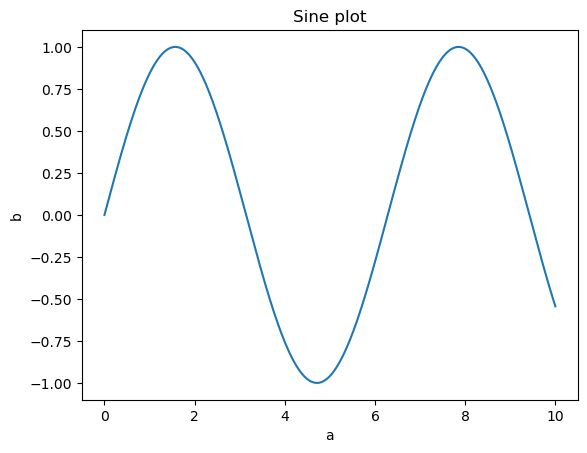

In [15]:
fig, ax = plt.subplots()
ax.plot(a,b)
ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_title("Sine plot")
# help(plt.plot())

Plot the cosine values (array `c`) on the same axes. Add a legend, mapping lines to labels. Hint: set `label` in `ax.plot()`; then call `plt.legend()`.

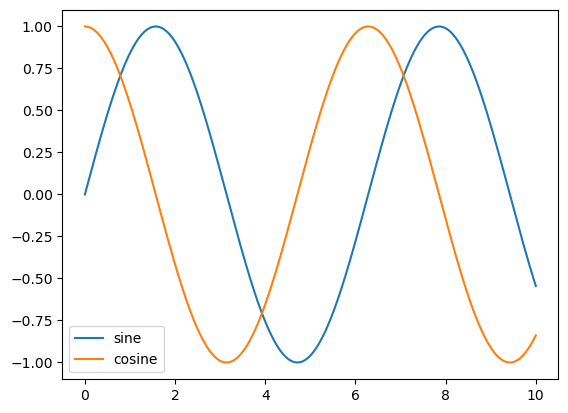

In [16]:
fig, ax = plt.subplots()
ax.plot(a,b, label="sine") # adapt this line, use the "label" argument
ax.plot(a,c, label="cosine") # adapt this line, use the "label" argument
# ...
plt.legend()

Now, draw the sine and cosine in two separate subplots. Complete the skeleton below for this. Use `ax1` for plotting the sine (array `b`), and `ax2` for plotting the cosine (array `c`). Add axis labels and subtitles.

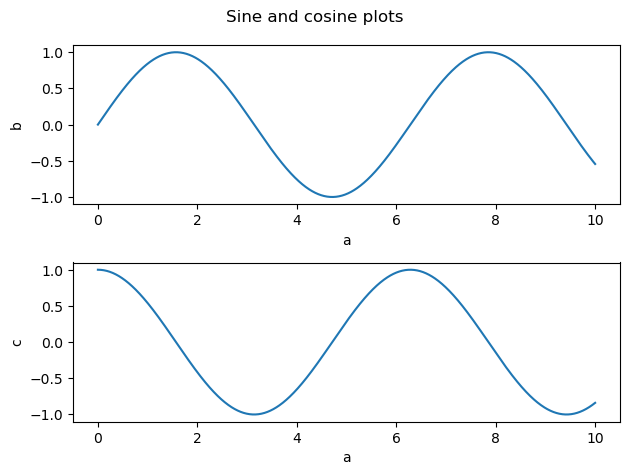

In [17]:
fig, [ax1,ax2] = plt.subplots(2,1)
fig.suptitle("Sine and cosine plots")
# ax1
# ...
ax1.plot(a,b, label='sine')
ax1.set_ylabel("b")
ax1.set_xlabel("a")
# ax2
# ...
ax2.plot(a, c, label='cosine')
ax2.set_ylabel("c")
ax2.set_xlabel("a")

fig.tight_layout()

Now write your own code block to plot the data from `ex0.npy` that you loaded in the previous part. Can you guess what this signal could be?

In [18]:
print(data)

[-3.04455261e+02 -2.61403561e+02 -2.18332372e+02 -1.75213763e+02
 -1.32014695e+02 -8.87033770e+01 -4.52557883e+01 -1.66241764e+00
  4.20647263e+01  8.58848216e+01  1.29720681e+02  1.73451028e+02
  2.16902753e+02  2.59843400e+02  3.01974230e+02  3.42924328e+02
  3.82246356e+02  4.19414687e+02  4.53826829e+02  4.84809176e+02
  5.11628300e+02  5.33509117e+02  5.49661398e+02  5.59316158e+02
  5.61773499e+02  5.56463423e+02  5.43020995e+02  5.21376973e+02
  4.91864609e+02  4.55342710e+02  4.13297146e+02  3.67807672e+02
  3.21488475e+02  2.77435430e+02  2.39174862e+02  2.10607623e+02
  1.95941462e+02  1.99603914e+02  2.26127298e+02  2.79997040e+02
  3.65454274e+02  4.86243845e+02  6.45299294e+02  8.44275746e+02
  1.08267987e+03  1.35683901e+03  1.65915125e+03  1.97870030e+03
  2.30217392e+03  2.61474862e+03  2.90096710e+03  3.14563761e+03
  3.33478604e+03  3.45669054e+03  3.50302665e+03  3.47014555e+03
  3.36000689e+03  3.17928718e+03  2.93814598e+03  2.64913211e+03
  2.32620982e+03  1.98388

Text(0.5, 1.0, 'Signal')

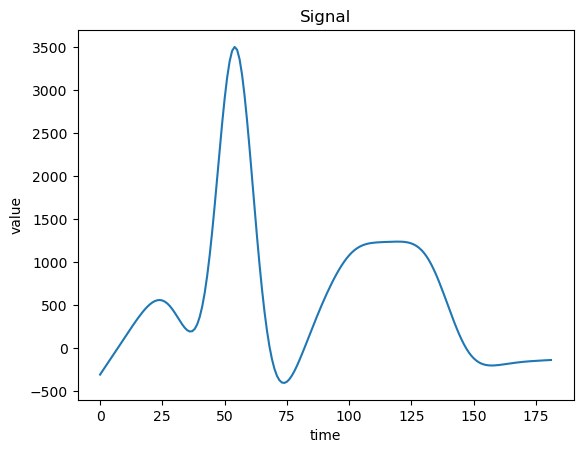

In [19]:
fig, ax_data = plt.subplots()
ax_data.plot(data)
ax_data.set_ylabel("value")
ax_data.set_xlabel("time")
ax_data.set_title("Signal")


In [20]:
# Y = np.fft.fft(data)
# freqs = np.fft.fftfreq(len(data))
# plt.plot(freqs, np.abs(Y))
# plt.title("Frequency Spectrum")

## Introduction to SciPy

SciPy builds on NumPy with algorithms for optimization, signal processing, statistics, interpolation, and more. For now, we’ll focus on normalization with `scipy.stats.zscore` and leave filtering/spectral analysis for later lessons.





In [21]:
import scipy

Use the function `scipy.stats.zscore()` to normalize the data that was loaded previously. Inspect the effect of normalization: what is now the minimum, maximum, and average value?

In [22]:
normalized_data = scipy.stats.zscore(data)
# print(normalized_data)
print("Normalized data min", normalized_data.min())
print("Normalized data max", normalized_data.max())
print("Normalized data mean", normalized_data.mean())

print("Data min", data.min())
print("Data max", data.max())
print("Data mean",data.mean())

Normalized data min -1.1713663349643084
Normalized data max 3.30638732361754
Normalized data mean 1.07362226557158e-16
Data min -401.54661365167794
Data max 3503.0266458225615
Data mean 619.8775238249955


Plot the normalized signal.

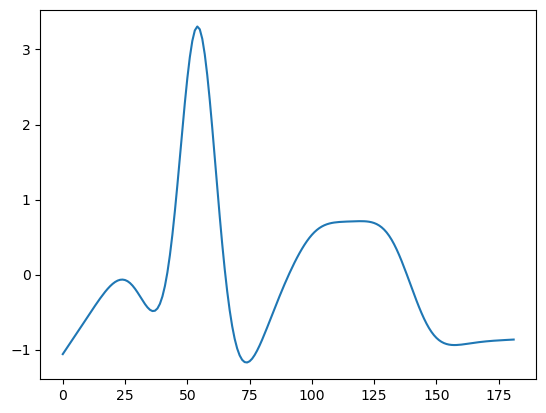

In [23]:
fig, ax_norm = plt.subplots()
ax_norm.plot(normalized_data)

## Introduction to type hints

Python is dynamically typed at runtime, but you can add static type hints to improve readability and enable tooling (linters, type checkers). Below, we demonstrate dynamic typing, where a variable can change type throughout a program without any issues.

In [24]:
def helloWorld():
  a = "hello"
  print(a)
  print(type(a))

  a = 1
  print(a)
  print(type(a))

helloWorld()

hello
<class 'str'>
1
<class 'int'>


However, you can annotate functions with type hints. Argument types follow a colon; the return type follows `->`. Tools can use these hints to detect mismatches before running your code.

In [25]:
def helloWorld(provideText: bool) -> None:
  if provideText:
    a = "hello"
    print(a)
    print(type(a))

  else:
    a = 1
    print(a)
    print(type(a))

helloWorld(provideText=True)

hello
<class 'str'>


In [26]:
helloWorld(provideText=False)

1
<class 'int'>


Type hints improve readability but do not enforce types at runtime. If you pass a string to `provideText` (expected `bool`), Python will treat non-empty strings as truthy in conditionals. Test this out. Can you explain the output?

In [27]:
helloWorld(provideText="providing a string")

hello
<class 'str'>


To catch type errors, you could enable static checking (e.g., in your IDE) or run a type checker such as `mypy` on your code. In Colab, you can also rely on editor diagnostics to flag mismatches (`Tools` > `Settings` > `Editor` > `Code diagnostics` > `Syntax and type checking`). Check what happens if you do this.

Note: Type hints are optional but recommended for larger projects and shared code. We'll use them in templates (especially around NumPy arrays) to improve readability and intent.